## **BackGround**
- Data Specs를 기준으로 여행자 특징, 여행 특징, 일자 특징을 기반으로 관광지 방문 순서를 생성하는 모델을 위한 적절한 데이터셋 형태를 탐색합니다.

    $$
    X = (\text{Traveler Features},\ \text{Travel Features},\ \text{Day Features}),
    \quad
    Y = [\text{POI}_1,\ \text{POI}_2,\ \ldots,\ \text{POI}_T]
    $$

- 여기서 \(T\)는 해당 여행 일자의 실제 POI 개수이며, 샘플마다 달라질 수 있는 가변 길이 시퀀스입니다.
- 모델 학습 시에는 `<EOS>` 토큰으로 시퀀스 종료를 표시하고, 배치 처리를 위해 필요한 경우 `<PAD>` 토큰으로 길이를 맞춥니다.
- 현재 데이터 기준 하루 최대 POI 길이는 11개이므로, 고정 길이 텐서가 필요한 단계에서는 최대 길이를 11 또는 `<EOS>` 포함 12로 둘 수 있습니다.

## **0. Data Specs**

- traveler_df(tn_traveller_master_여행객_Master) : 
    - traveler_id(TRAVELER_ID) : 여행자 고유 ID
    - residence_code(RESIDENCE_SGG_CD) : 거주 지역 코드 (17개 중 하나)
    - gender(GENDER) : 성별 (남/여)
    - age_grp(AGE_GRP) : 나이대(20,30,40,50,60 중 하나)
    - travel_style(TRAVEL_STYL_1) : 자연 - 도시 선호 유형 (1,2,3,4,5,6,7 중 하나)
    - travel_like_code(TRAVEL_LIKE_SIDO_1) : 선호 여행 지역 코드 (17개 중 하나)
---
- travel_df(tn_travel_여행) : 
    - travel_id(TRAVEL_ID) : 여행 고유 ID
    - traveler_id(TRAVELER_ID) : 여행자 고유 ID
    - area_code(visit_area_df 가공) : 지역별 테마 여행 지역 코드 (9개 중 하나)
        - _지역별 테마 여행 분류 기준은 VISIT_START_YMD&&TRAVEL_ID가 동일한 VISIT_AREA_ID의 SGG_CD의 가장 비율 높은 지역의 지역 코드로 설정_
    - companion_bucket(TRAVEL_COMPANIONS_NUM) : 동반자 수 (0~2, 2+~=2)
    - theme_multi_hot(TRAVEL_MISSION_CHECK 가공) : 여행 컨셉  
        - _EDA의 mission_theme_map을 기준으로 TRAVEL_MISSION_CHECK 재분류_
        - 원핫인코딩 형식으로 최소 1개에서 최대 3개는 1

---
- visit_area_df(tn_visit_area_info_방문지정보) : 
    - travel_id(TRAVEL_ID) : 여행 고유 ID 
    - visit_day(VISIT_START_YMD&) : 여행지 방문 일자(_시작과 종료일 별도로 존재하지만 시작일로 가정_) 
    - visit_area_id(VISIT_AREA_ID) : 방문한 여행지 고유 ID
    - visit_order(VISIT_ORDER) :  방문 순서 
    - visit_area_nm(VISIT_AREA_NM) : 방문지 이름 (참고용)
---
- content_id_df(total_travel_seq_with_contentid) : 
    - visit_area_id(VISIT_AREA_ID) : 방문한 여행지 고유 ID
    - content_id(CONTENT_ID) : 한국관광공사 API 호출 가능한 관광지 ID 

## **1. Load Data**

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.preprocess.io import load_all_tables
from src.preprocess.contentid_sequences import row_theme_area
from src.preprocess.sequences import legal_dong_code

In [2]:
RAW_ROOT = PROJECT_ROOT / "data" / "raw"
PROCESSED_ROOT = PROJECT_ROOT / "data" / "processed"
CONTENT_ID_PATH = PROCESSED_ROOT / "total_travel_seq_with_contentid.csv"

In [3]:
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

tables = load_all_tables(RAW_ROOT)
travel_raw = tables["travel"]
traveller_raw = tables["traveller"]
visit_area_raw = tables["visit"]
content_id_raw = pd.read_csv(CONTENT_ID_PATH, encoding="utf-8-sig", dtype="string")

print(f"RAW_ROOT: {RAW_ROOT}")
print(f"CONTENT_ID_PATH: {CONTENT_ID_PATH}")
print("travel_raw:", travel_raw.shape)
print("traveller_raw:", traveller_raw.shape)
print("visit_area_raw:", visit_area_raw.shape)
print("content_id_raw:", content_id_raw.shape)


RAW_ROOT: s:\Study\AI\data\raw
CONTENT_ID_PATH: s:\Study\AI\data\processed\total_travel_seq_with_contentid.csv
travel_raw: (8640, 12)
traveller_raw: (8640, 38)
visit_area_raw: (88959, 25)
content_id_raw: (71649, 16)


## **2. Preprocess**

### 2.1 Traveler

In [4]:
traveler_df = (
    traveller_raw
    .drop_duplicates("TRAVELER_ID", keep="first")
    .rename(
        columns={
            "TRAVELER_ID": "traveler_id",
            "RESIDENCE_SGG_CD": "residence_code",
            "GENDER": "gender",
            "AGE_GRP": "age_grp",
            "TRAVEL_STYL_1": "travel_style",
            "TRAVEL_LIKE_SIDO_1": "travel_like_code",
        }
    )[
        [
            "traveler_id",
            "residence_code",
            "gender",
            "age_grp",
            "travel_style",
            "travel_like_code",
        ]
    ]
    .reset_index(drop=True)
)

print("traveler_df:", traveler_df.shape)
display(traveler_df.head())
display(traveler_df.isna().sum().rename("missing_count").to_frame())


traveler_df: (8640, 6)


,traveler_id,residence_code,gender,age_grp,travel_style,travel_like_code
0,e004720,41,여,60,2,11
1,e000914,30,여,20,3,45
2,e003564,41,여,30,1,42
3,e000396,41,여,30,3,50
4,e001890,11,남,20,6,42


,missing_count
traveler_id,0
residence_code,0
gender,0
age_grp,0
travel_style,0
travel_like_code,0


### 2.2 Travel

In [5]:
mission_theme_map = {
    "22": "hotplace_sentiment",
    "1": "city_shopping",
    "4": "city_shopping",
    "3": "culture_history",
    "6": "culture_history",
    "2": "play_experience",
    "9": "play_experience",
    "11": "play_experience",
    "25": "play_experience",
    "5": "nature_activity",
    "8": "nature_activity",
    "27": "nature_activity",
    "24": "nature_activity",
    "21": "rest_wellness",
    "10": "rest_wellness",
    "23": "rest_wellness",
    "26": "contents_special",
    "12": "contents_special",
    "13": "contents_special",
}

theme_order = [
    "hotplace_sentiment",
    "city_shopping",
    "culture_history",
    "play_experience",
    "nature_activity",
    "rest_wellness",
    "contents_special",
]
theme_columns = [f"theme_{theme}" for theme in theme_order]

In [6]:
def split_codes(value):
    if pd.isna(value) or str(value).strip() == "":
        return []
    return [code.strip() for code in str(value).split(";") if code.strip()]


def companion_bucket(value):
    value = pd.to_numeric(pd.Series([value]), errors="coerce").iloc[0]
    if pd.isna(value):
        return 0
    return int(min(max(value, 0), 2))


In [7]:
travel_profile = travel_raw.merge(
    traveller_raw[["TRAVELER_ID", "TRAVEL_COMPANIONS_NUM"]].drop_duplicates("TRAVELER_ID"),
    on="TRAVELER_ID",
    how="left",
    validate="many_to_one",
)

travel_df = pd.DataFrame(
    {
        "trip_id": travel_profile["TRAVEL_ID"],
        "traveler_id": travel_profile["TRAVELER_ID"],
        "trip_days": (
            pd.to_datetime(travel_profile["TRAVEL_END_YMD"], errors="coerce")
            - pd.to_datetime(travel_profile["TRAVEL_START_YMD"], errors="coerce")
        ).dt.days + 1,
        "companion_bucket": travel_profile["TRAVEL_COMPANIONS_NUM"].map(companion_bucket),
        "travel_mission_check": travel_profile["TRAVEL_MISSION_CHECK"],
    }
)
travel_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8640 entries, 0 to 8639
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   trip_id               8640 non-null   string
 1   traveler_id           8640 non-null   string
 2   trip_days             8640 non-null   int64 
 3   companion_bucket      8640 non-null   int64 
 4   travel_mission_check  8640 non-null   string
dtypes: int64(2), string(3)
memory usage: 337.6 KB


In [8]:
travel_theme_sets = travel_df["travel_mission_check"].map(
    lambda value: sorted({mission_theme_map[code] for code in split_codes(value) if code in mission_theme_map})
)
unmapped_mission_codes = sorted(
    {
        code
        for value in travel_df["travel_mission_check"].dropna()
        for code in split_codes(value)
        if code not in mission_theme_map
    }
)

for theme in theme_order:
    travel_df[f"theme_{theme}"] = travel_theme_sets.map(lambda themes, theme=theme: int(theme in themes))

travel_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8640 entries, 0 to 8639
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   trip_id                   8640 non-null   string
 1   traveler_id               8640 non-null   string
 2   trip_days                 8640 non-null   int64 
 3   companion_bucket          8640 non-null   int64 
 4   travel_mission_check      8640 non-null   string
 5   theme_hotplace_sentiment  8640 non-null   int64 
 6   theme_city_shopping       8640 non-null   int64 
 7   theme_culture_history     8640 non-null   int64 
 8   theme_play_experience     8640 non-null   int64 
 9   theme_nature_activity     8640 non-null   int64 
 10  theme_rest_wellness       8640 non-null   int64 
 11  theme_contents_special    8640 non-null   int64 
dtypes: int64(9), string(3)
memory usage: 810.1 KB


In [9]:
visit_area_df = visit_area_raw[
    [
        "TRAVEL_ID",
        "VISIT_START_YMD",
        "VISIT_AREA_ID",
        "VISIT_ORDER",
        "VISIT_AREA_NM",
        "LOTNO_CD",
        "SGG_CD",
        "ROAD_NM_ADDR",
        "LOTNO_ADDR",
    ]
].copy()
visit_area_df["LEGAL_DONG_CD"] = [
    legal_dong_code(lotno_cd, sgg_cd)
    for lotno_cd, sgg_cd in zip(visit_area_df["LOTNO_CD"], visit_area_df["SGG_CD"])
]
visit_area_df = visit_area_df.merge(
    travel_raw[["TRAVEL_ID", "TRAVEL_START_YMD"]],
    on="TRAVEL_ID",
    how="inner",
    validate="many_to_one",
)
visit_area_df["day_index"] = (
    pd.to_datetime(visit_area_df["VISIT_START_YMD"], errors="coerce")
    - pd.to_datetime(visit_area_df["TRAVEL_START_YMD"], errors="coerce")
).dt.days + 1
visit_area_df = visit_area_df[visit_area_df["day_index"].between(1, 3)].copy()
visit_area_df["day_index"] = visit_area_df["day_index"].astype("int64")
visit_area_df["area_code"] = visit_area_df.apply(lambda row: row_theme_area(row.to_dict()) or pd.NA, axis=1)

area_by_day = (
    visit_area_df.dropna(subset=["area_code"])
    .groupby(["TRAVEL_ID", "day_index"])["area_code"]
    .agg(lambda series: series.value_counts().sort_values(ascending=False).index[0])
    .rename("area_code")
    .reset_index()
    .rename(columns={"TRAVEL_ID": "trip_id"})
)

travel_day_df = (
    visit_area_df[["TRAVEL_ID", "day_index"]]
    .drop_duplicates()
    .rename(columns={"TRAVEL_ID": "trip_id"})
    .merge(travel_df.drop(columns=["travel_mission_check"]), on="trip_id", how="left", validate="many_to_one")
    .merge(area_by_day, on=["trip_id", "day_index"], how="left", validate="one_to_one")
)

theme_sum = travel_df[theme_columns].sum(axis=1)
print("travel_df:", travel_df.shape)
print("travel_day_df:", travel_day_df.shape)
print("unmapped TRAVEL_MISSION_CHECK codes:", unmapped_mission_codes)
print("theme multi-hot sum counts:")
display(theme_sum.value_counts(dropna=False).sort_index().rename("travel_count").to_frame())
print("area_code distribution:")
display(travel_day_df["area_code"].value_counts(dropna=False).rename("day_count").to_frame())
display(travel_day_df.head())


travel_df: (8640, 12)
travel_day_df: (13472, 13)
unmapped TRAVEL_MISSION_CHECK codes: ['28', '7']
theme multi-hot sum counts:


,travel_count
1,141
2,2781
3,5718


area_code distribution:


,day_count
area_code,
NaN,4058
seoul,4007
daejeon,1142
busan,1084
daegu,970
incheon,748
gwangju,652
suwon,614
changwon,197


,trip_id,day_index,traveler_id,trip_days,companion_bucket,theme_hotplace_sentiment,theme_city_shopping,theme_culture_history,theme_play_experience,theme_nature_activity,theme_rest_wellness,theme_contents_special,area_code
0,e_e000004,1,e000004,2,2,0,1,1,1,0,0,0,suwon
1,e_e000006,1,e000006,3,1,0,0,0,0,1,1,0,seoul
2,e_e000006,2,e000006,3,1,0,0,0,0,1,1,0,seoul
3,e_e000009,1,e000009,3,1,1,1,0,0,0,0,0,NaN
4,e_e000009,2,e000009,3,1,1,1,0,0,0,0,0,incheon


### 2.3 ContentId

#### 2.3.1 POI 길이 탐색

- 기존 `content_id_df` 생성과 동일하게 `content_id_raw`에서 `content_id`가 있는 방문지만 사용한다.
- `day_index`, `visit_order` 타입 변환, `travel_id/day_index/content_id` 중복 제거, 정렬 기준을 기존 로직과 맞춘다.
- `poi_rank`를 자르기 전에 `travel_id + day_index`별 POI 개수를 집계해 최대 길이를 계산한다.
- 최대 길이를 가진 여행 일자 예시와 POI 개수 분포를 함께 출력해, `POI_1`부터 어디까지 필요한지 확인한다.


In [10]:
poi_length_source_df = (
    content_id_raw
    .rename(columns={"CONTENT_ID": "content_id"})
    [["travel_id", "day_index", "visit_order", "visit_area_id", "content_id"]]
    .dropna(subset=["content_id"])
    .copy()
)
poi_length_source_df["day_index"] = pd.to_numeric(poi_length_source_df["day_index"], errors="coerce").astype("Int64")
poi_length_source_df["visit_order"] = pd.to_numeric(poi_length_source_df["visit_order"], errors="coerce").astype("Int64")
poi_length_source_df = (
    poi_length_source_df
    .sort_values(["travel_id", "day_index", "visit_order", "visit_area_id"], kind="mergesort")
    .drop_duplicates(["travel_id", "day_index", "content_id"], keep="first")
)

poi_length_by_day = (
    poi_length_source_df
    .groupby(["travel_id", "day_index"], dropna=False)
    .size()
    .rename("poi_count")
    .reset_index()
    .sort_values(["poi_count", "travel_id", "day_index"], ascending=[False, True, True], kind="mergesort")
)
max_poi_length = int(poi_length_by_day["poi_count"].max())
max_poi_days = poi_length_by_day[poi_length_by_day["poi_count"].eq(max_poi_length)]

print("max POI length per travel_id/day_index:", max_poi_length)
print("number of travel_id/day_index rows at max length:", len(max_poi_days))
display(max_poi_days.head(20))
display(
    poi_length_by_day["poi_count"]
    .value_counts()
    .sort_index()
    .rename_axis("poi_count")
    .rename("travel_day_count")
    .to_frame()
)


max POI length per travel_id/day_index: 11
number of travel_id/day_index rows at max length: 1


,travel_id,day_index,poi_count
759,e_e007488,1,11


,travel_day_count
poi_count,
1,1024
2,675
3,354
4,170
5,47
6,34
7,11
8,3
9,2


In [11]:
content_id_df = (
    content_id_raw
    .rename(columns={"CONTENT_ID": "content_id"})
    [["travel_id", "day_index", "visit_order", "visit_area_id", "content_id"]]
    .dropna(subset=["content_id"])
    .copy()
)
content_id_df["day_index"] = pd.to_numeric(content_id_df["day_index"], errors="coerce").astype("Int64")
content_id_df["visit_order"] = pd.to_numeric(content_id_df["visit_order"], errors="coerce").astype("Int64")
content_id_df = (
    content_id_df
    .sort_values(["travel_id", "day_index", "visit_order", "visit_area_id"], kind="mergesort")
    .drop_duplicates(["travel_id", "day_index", "content_id"], keep="first")
)
content_id_ranked = content_id_df.copy()
content_id_ranked["poi_rank"] = content_id_ranked.groupby(["travel_id", "day_index"]).cumcount() + 1
content_id_ranked = content_id_ranked[content_id_ranked["poi_rank"].between(1, 6)].copy()

poi_df = (
    content_id_ranked
    .pivot(index=["travel_id", "day_index"], columns="poi_rank", values="content_id")
    .rename(columns=lambda rank: f"poi_{rank}")
    .reset_index()
    .rename(columns={"travel_id": "trip_id"})
)
for poi_idx in range(1, 7):
    column = f"poi_{poi_idx}"
    if column not in poi_df.columns:
        poi_df[column] = pd.NA

modeling_df = (
    travel_day_df
    .merge(traveler_df, on="traveler_id", how="left", validate="many_to_one")
    .merge(poi_df, on=["trip_id", "day_index"], how="left", validate="one_to_one")
    .dropna(subset=["poi_1"])
    .sort_values(["trip_id", "day_index"], kind="mergesort")
    .reset_index(drop=True)
)

poi_columns = [f"poi_{idx}" for idx in range(1, 7)]
duplicated_trip_days = modeling_df.duplicated(["trip_id", "day_index"]).sum()
empty_poi_1 = modeling_df["poi_1"].isna().sum()
duplicated_poi_rows = modeling_df[poi_columns].apply(lambda row: row.dropna().duplicated().any(), axis=1).sum()

print("content_id_df:", content_id_df.shape)
print("modeling_df:", modeling_df.shape)
print("duplicated trip_id/day_index rows:", duplicated_trip_days)
print("empty poi_1 rows:", empty_poi_1)
print("rows with duplicate POIs:", duplicated_poi_rows)
display(modeling_df[poi_columns].notna().sum().rename("non_null_count").to_frame())
display(modeling_df.isna().sum().rename("missing_count").to_frame())
display(modeling_df.head())


content_id_df: (4685, 5)
modeling_df: (2321, 24)
duplicated trip_id/day_index rows: 0
empty poi_1 rows: 0
rows with duplicate POIs: 0


,non_null_count
poi_1,2321
poi_2,1297
poi_3,622
poi_4,268
poi_5,98
poi_6,51


,missing_count
trip_id,0
day_index,0
traveler_id,0
trip_days,0
companion_bucket,0
theme_hotplace_sentiment,0
theme_city_shopping,0
theme_culture_history,0
theme_play_experience,0
theme_nature_activity,0


,trip_id,day_index,traveler_id,trip_days,companion_bucket,theme_hotplace_sentiment,theme_city_shopping,theme_culture_history,theme_play_experience,theme_nature_activity,theme_rest_wellness,theme_contents_special,area_code,residence_code,gender,age_grp,travel_style,travel_like_code,poi_1,poi_2,poi_3,poi_4,poi_5,poi_6
0,e_e000004,1,e000004,2,2,0,1,1,1,0,0,0,suwon,41,남,40,5,50,264392,264394,<NA>,<NA>,<NA>,<NA>
1,e_e000021,2,e000021,3,1,0,0,1,0,1,1,0,seoul,11,남,20,6,42,2758150,<NA>,<NA>,<NA>,<NA>,<NA>
2,e_e000023,1,e000023,2,2,0,1,1,1,0,0,0,seoul,28,남,60,4,46,2381373,775394,126508,<NA>,<NA>,<NA>
3,e_e000030,1,e000030,2,0,0,0,0,0,0,1,0,seoul,11,남,50,2,41,2758150,<NA>,<NA>,<NA>,<NA>,<NA>
4,e_e000040,1,e000040,3,1,0,1,1,0,0,0,0,seoul,41,남,30,2,50,2495561,128162,<NA>,<NA>,<NA>,<NA>


#### 2.3.2 POI 카테고리 분석
* 카테고리별 POI의 개수를 시각화해 추후 전처리에 참고합니다. 

In [12]:
import matplotlib.pyplot as plt

content_type_map = {
    "12": "관광지",
    "14": "문화시설",
    "15": "축제/공연/행사",
    "25": "여행코스",
    "28": "레포츠",
    "32": "숙박",
    "38": "쇼핑",
    "39": "음식점",
}


def content_type_label(value):
    if pd.isna(value) or str(value).strip() == "":
        return "missing"
    content_type_id = str(value).strip()
    return content_type_map.get(content_type_id, f"unknown_{content_type_id}")


poi_category_df = (
    content_id_raw
    .rename(columns={"CONTENT_ID": "content_id", "CONTENT_TYPE_ID": "content_type_id"})
    [["travel_id", "day_index", "visit_order", "visit_area_id", "content_id", "content_type_id"]]
    .dropna(subset=["content_id"])
    .copy()
)
poi_category_df["day_index"] = pd.to_numeric(poi_category_df["day_index"], errors="coerce").astype("Int64")
poi_category_df["visit_order"] = pd.to_numeric(poi_category_df["visit_order"], errors="coerce").astype("Int64")
poi_category_df = (
    poi_category_df
    .sort_values(["travel_id", "day_index", "visit_order", "visit_area_id"], kind="mergesort")
    .drop_duplicates(["travel_id", "day_index", "content_id"], keep="first")
    .reset_index(drop=True)
)
poi_category_df["content_type_label"] = poi_category_df["content_type_id"].map(content_type_label)

content_type_missing_mask = (
    poi_category_df["content_type_id"].isna()
    | poi_category_df["content_type_id"].astype("string").str.strip().eq("").fillna(False)
)
content_type_missing_count = int(content_type_missing_mask.sum())

category_occurrence_summary = (
    poi_category_df
    .groupby(["content_type_id", "content_type_label"], dropna=False)
    .size()
    .rename("occurrence_count")
    .reset_index()
    .sort_values("occurrence_count", ascending=False, kind="mergesort")
)
category_occurrence_summary["occurrence_ratio"] = (
    category_occurrence_summary["occurrence_count"] / len(poi_category_df)
).round(4)

category_unique_summary = (
    poi_category_df
    .groupby(["content_type_id", "content_type_label"], dropna=False)["content_id"]
    .nunique()
    .rename("unique_poi_count")
    .reset_index()
    .sort_values("unique_poi_count", ascending=False, kind="mergesort")
)
category_unique_summary["unique_poi_ratio"] = (
    category_unique_summary["unique_poi_count"] / poi_category_df["content_id"].nunique()
).round(4)

assert category_occurrence_summary["occurrence_count"].sum() == len(poi_category_df)
assert category_unique_summary["unique_poi_count"].sum() == poi_category_df["content_id"].nunique()

print("total POI occurrence rows:", len(poi_category_df))
print("unique POI count:", poi_category_df["content_id"].nunique())
print("missing CONTENT_TYPE_ID rows:", content_type_missing_count)
display(category_occurrence_summary)
display(category_unique_summary)



total POI occurrence rows: 4685
unique POI count: 972
missing CONTENT_TYPE_ID rows: 0


,content_type_id,content_type_label,occurrence_count,occurrence_ratio
0,12,관광지,2266,0.4837
7,39,음식점,827,0.1765
6,38,쇼핑,719,0.1535
1,14,문화시설,717,0.1530
4,28,레포츠,118,0.0252
5,32,숙박,29,0.0062
2,15,축제/공연/행사,6,0.0013
3,25,여행코스,3,0.0006


,content_type_id,content_type_label,unique_poi_count,unique_poi_ratio
0,12,관광지,330,0.3395
7,39,음식점,261,0.2685
6,38,쇼핑,166,0.1708
1,14,문화시설,160,0.1646
4,28,레포츠,36,0.0370
5,32,숙박,17,0.0175
2,15,축제/공연/행사,1,0.0010
3,25,여행코스,1,0.0010


C:\Users\82103\AppData\Local\Temp\ipykernel_8404\4167309310.py:27: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82103\AppData\Local\Temp\ipykernel_8404\4167309310.py:27: UserWarning: Glyph 44305 (\N{HANGUL SYLLABLE GWANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82103\AppData\Local\Temp\ipykernel_8404\4167309310.py:27: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82103\AppData\Local\Temp\ipykernel_8404\4167309310.py:27: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82103\AppData\Local\Temp\ipykernel_8404\4167309310.py:27: UserWarning: Glyph 49885 (\N{HANGUL SYLLABLE SIG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82103\AppData\Local\Temp\ipykernel_8404\4167309310.py:27: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from f

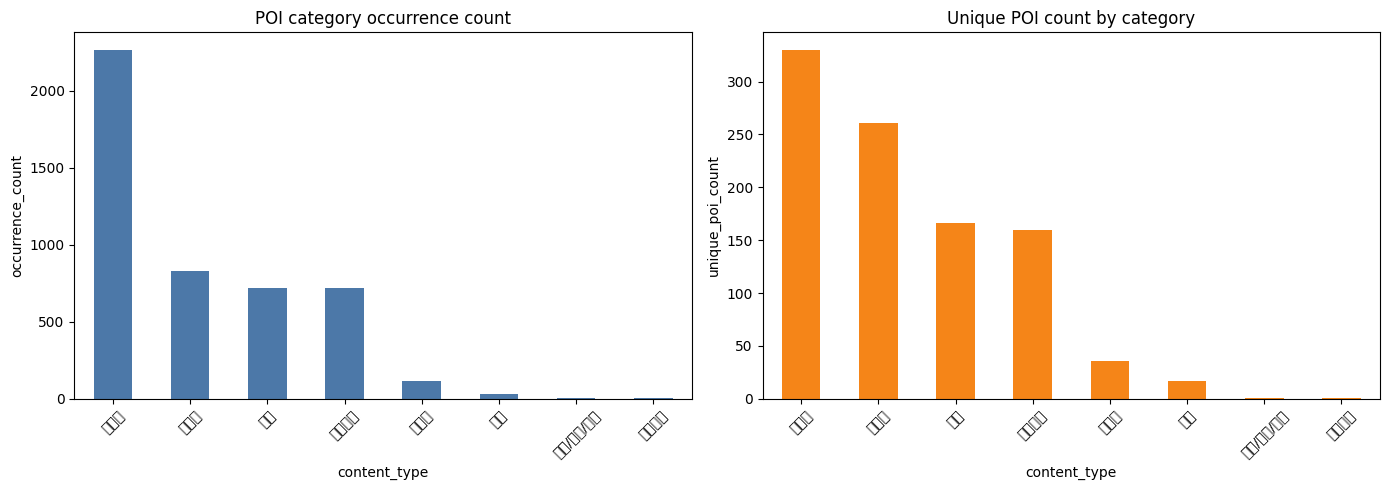

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

category_occurrence_summary.plot.bar(
    x="content_type_label",
    y="occurrence_count",
    ax=axes[0],
    legend=False,
    color="#4C78A8",
)
axes[0].set_title("POI category occurrence count")
axes[0].set_xlabel("content_type")
axes[0].set_ylabel("occurrence_count")
axes[0].tick_params(axis="x", rotation=45)

category_unique_summary.plot.bar(
    x="content_type_label",
    y="unique_poi_count",
    ax=axes[1],
    legend=False,
    color="#F58518",
)
axes[1].set_title("Unique POI count by category")
axes[1].set_xlabel("content_type")
axes[1].set_ylabel("unique_poi_count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


#### 2.3.3 POI별 장애 정보 분석 
* [한국관광공사_무장애 여행 정보](https://www.data.go.kr/data/15101897/openapi.do)를 호출해 POI별로 장애 피쳐(노인, 장애, 아이)를 추가합니다. 
* POI의 장애 정보 분포를 시각화해 추후 모델링에 참고합니다. 

In [20]:
import json
import socket
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from urllib.error import HTTPError, URLError
from urllib.request import urlopen

from src.preprocess.io import read_env_keys
from src.preprocess.tourapi import build_tourapi_url, is_key_fallback_error, parse_tourapi_items

BARRIERFREE_DETAIL_BASE_URL = "https://apis.data.go.kr/B551011/KorWithService2/detailWithTour2"
BARRIERFREE_CACHE_PATH = PROCESSED_ROOT / "tourapi_barrierfree_detail_cache.jsonl"
MAX_BARRIERFREE_API_CALLS = 900
BARRIERFREE_REQUEST_TIMEOUT = 5.0
BARRIERFREE_REQUEST_RETRIES = 1
BARRIERFREE_RETRY_SLEEP = 0.5
BARRIERFREE_REQUEST_SLEEP = 0.02
BARRIERFREE_PARALLEL_WORKERS = 8

In [21]:
def load_barrierfree_detail_cache(cache_path):
    cache = {}
    if not cache_path.exists():
        return cache
    with cache_path.open("r", encoding="utf-8") as fp:
        for line in fp:
            line = line.strip()
            if not line:
                continue
            try:
                record = json.loads(line)
            except json.JSONDecodeError:
                continue
            content_id = record.get("contentid")
            if content_id:
                cache[str(content_id)] = record
    return cache


def append_barrierfree_detail_cache(cache_path, record):
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    with cache_path.open("a", encoding="utf-8") as fp:
        fp.write(json.dumps(record, ensure_ascii=False) + "\n")


def fetch_barrierfree_detail(content_id, service_key, base_url, timeout, retries, retry_sleep):
    params = {
        "serviceKey": service_key,
        "MobileOS": "ETC",
        "MobileApp": "kor_travel_recommendation",
        "_type": "json",
        "numOfRows": 10,
        "pageNo": 1,
        "contentId": content_id,
    }
    url = build_tourapi_url(base_url, params)
    payload = None
    last_error = None
    for attempt in range(retries + 1):
        try:
            with urlopen(url, timeout=timeout) as response:
                payload = json.loads(response.read().decode("utf-8"))
            break
        except (HTTPError, URLError, TimeoutError, socket.timeout, OSError, json.JSONDecodeError) as exc:
            last_error = f"{type(exc).__name__}: {exc}"
            if attempt < retries:
                time.sleep(retry_sleep * (attempt + 1))
                continue
            return {
                "contentid": str(content_id),
                "status": "api_error",
                "items": [],
                "error": last_error,
            }

    if payload is None:
        return {
            "contentid": str(content_id),
            "status": "api_error",
            "items": [],
            "error": last_error or "empty response",
        }

    header = payload.get("response", {}).get("header", {})
    result_code = str(header.get("resultCode", ""))
    if result_code and result_code != "0000":
        return {
            "contentid": str(content_id),
            "status": "api_error",
            "items": [],
            "error": header.get("resultMsg", f"resultCode={result_code}"),
        }

    items = parse_tourapi_items(payload)
    return {
        "contentid": str(content_id),
        "status": "ok" if items else "no_result",
        "items": items,
        "error": None,
    }


def fetch_barrierfree_detail_with_keys(content_id, service_keys, start_key_index=0):
    if not service_keys:
        return {
            "contentid": str(content_id),
            "status": "api_error",
            "items": [],
            "error": "no API keys provided",
        }

    key_count = len(service_keys)
    rotated_keys = service_keys[start_key_index % key_count:] + service_keys[: start_key_index % key_count]
    last_record = None
    for key_index, (key_name, service_key) in enumerate(rotated_keys):
        record = fetch_barrierfree_detail(
            content_id=content_id,
            service_key=service_key,
            base_url=BARRIERFREE_DETAIL_BASE_URL,
            timeout=BARRIERFREE_REQUEST_TIMEOUT,
            retries=BARRIERFREE_REQUEST_RETRIES,
            retry_sleep=BARRIERFREE_RETRY_SLEEP,
        )
        record["api_key_name"] = key_name
        last_record = record
        if is_key_fallback_error(record) and key_index < key_count - 1:
            continue
        return record
    return last_record



In [26]:

if "poi_category_df" in globals():
    barrierfree_content_ids = sorted(poi_category_df["content_id"].dropna().astype("string").unique().tolist())
else:
    barrierfree_content_ids = sorted(
        content_id_raw["CONTENT_ID"].dropna().astype("string").drop_duplicates().tolist()
    )

barrierfree_detail_cache = load_barrierfree_detail_cache(BARRIERFREE_CACHE_PATH)
pending_barrierfree_content_ids = [
    content_id for content_id in barrierfree_content_ids if content_id not in barrierfree_detail_cache
]

service_keys = read_env_keys(PROJECT_ROOT / ".env", ["DATA_OPENAPI_KEY"])
if pending_barrierfree_content_ids and not service_keys:
    raise RuntimeError("DATA_OPENAPI_KEY was not found in .env. Add the key before calling the barrier-free API.")

api_call_content_ids = pending_barrierfree_content_ids[:MAX_BARRIERFREE_API_CALLS]
completed_api_calls = 0

if api_call_content_ids:
    worker_count = min(BARRIERFREE_PARALLEL_WORKERS, len(api_call_content_ids))
    print(f"parallel workers: {worker_count}")
    with ThreadPoolExecutor(max_workers=worker_count) as executor:
        future_to_content_id = {}
        for key_index, content_id in enumerate(api_call_content_ids):
            future = executor.submit(
                fetch_barrierfree_detail_with_keys,
                content_id,
                service_keys,
                key_index,
            )
            future_to_content_id[future] = content_id
            if BARRIERFREE_REQUEST_SLEEP > 0:
                time.sleep(BARRIERFREE_REQUEST_SLEEP)

        for future in as_completed(future_to_content_id):
            content_id = future_to_content_id[future]
            try:
                record = future.result()
            except Exception as exc:
                record = {
                    "contentid": str(content_id),
                    "status": "api_error",
                    "items": [],
                    "error": f"{type(exc).__name__}: {exc}",
                }
            barrierfree_detail_cache[content_id] = record
            append_barrierfree_detail_cache(BARRIERFREE_CACHE_PATH, record)
            completed_api_calls += 1
            if completed_api_calls % 25 == 0 or completed_api_calls == len(api_call_content_ids):
                print(f"{completed_api_calls}/{len(api_call_content_ids)} fetched")

print("target unique POI count:", len(barrierfree_content_ids))
print("cached POI count:", len(barrierfree_detail_cache))
print("new API calls:", len(api_call_content_ids))
print("remaining uncached POI count:", max(len(pending_barrierfree_content_ids) - len(api_call_content_ids), 0))


parallel workers: 8
25/900 fetched
50/900 fetched
75/900 fetched
100/900 fetched
125/900 fetched
150/900 fetched
175/900 fetched
200/900 fetched
225/900 fetched
250/900 fetched
275/900 fetched
300/900 fetched
325/900 fetched
350/900 fetched
375/900 fetched
400/900 fetched
425/900 fetched
450/900 fetched
475/900 fetched
500/900 fetched
525/900 fetched
550/900 fetched
575/900 fetched
600/900 fetched
625/900 fetched
650/900 fetched
675/900 fetched
700/900 fetched
725/900 fetched
750/900 fetched
775/900 fetched
800/900 fetched
825/900 fetched
850/900 fetched
875/900 fetched
900/900 fetched
target unique POI count: 972
cached POI count: 900
new API calls: 900
remaining uncached POI count: 72


In [27]:
import matplotlib.pyplot as plt

if "barrierfree_detail_cache" not in globals():
    barrierfree_detail_cache = load_barrierfree_detail_cache(BARRIERFREE_CACHE_PATH)

if "barrierfree_content_ids" not in globals():
    if "poi_category_df" in globals():
        barrierfree_content_ids = sorted(poi_category_df["content_id"].dropna().astype("string").unique().tolist())
    else:
        barrierfree_content_ids = sorted(
            content_id_raw["CONTENT_ID"].dropna().astype("string").drop_duplicates().tolist()
        )


def first_barrierfree_item(record):
    items = record.get("items") or []
    if not items:
        return {}
    first_item = items[0]
    return first_item if isinstance(first_item, dict) else {}


def join_text_values(row):
    values = []
    for value in row.values:
        if pd.isna(value):
            continue
        text = str(value).strip()
        if text:
            values.append(text)
    return " ".join(values)


def contains_any_keyword(text, keywords):
    return int(any(keyword in text for keyword in keywords))




In [28]:
poi_accessibility_raw_rows = []
for content_id in barrierfree_content_ids:
    record = barrierfree_detail_cache.get(content_id, {})
    row = {
        "content_id": content_id,
        "api_status": record.get("status", "not_cached"),
        "api_error": record.get("error"),
    }
    row.update(first_barrierfree_item(record))
    poi_accessibility_raw_rows.append(row)

poi_accessibility_raw_df = pd.DataFrame(poi_accessibility_raw_rows)
poi_accessibility_df = poi_accessibility_raw_df.copy()

metadata_columns = {"content_id", "api_status", "api_error"}
text_columns = [column for column in poi_accessibility_df.columns if column not in metadata_columns]
poi_accessibility_df["accessibility_text"] = poi_accessibility_df[text_columns].apply(join_text_values, axis=1)

elderly_keywords = ["노약자", "고령", "어르신", "노인", "경로"]
disabled_keywords = ["장애", "휠체어", "점자", "보조견", "장애인", "무장애", "엘리베이터", "경사로"]
child_keywords = ["유아", "영유아", "수유", "기저귀", "유모차", "어린이", "아동"]

poi_accessibility_df["has_elderly_info"] = poi_accessibility_df["accessibility_text"].map(
    lambda text: contains_any_keyword(text, elderly_keywords)
)
poi_accessibility_df["has_disabled_info"] = poi_accessibility_df["accessibility_text"].map(
    lambda text: contains_any_keyword(text, disabled_keywords)
)
poi_accessibility_df["has_child_info"] = poi_accessibility_df["accessibility_text"].map(
    lambda text: contains_any_keyword(text, child_keywords)
)
poi_accessibility_df["has_any_accessibility_info"] = (
    poi_accessibility_df[["has_elderly_info", "has_disabled_info", "has_child_info"]].sum(axis=1).gt(0).astype(int)
)

feature_columns = [
    "has_elderly_info",
    "has_disabled_info",
    "has_child_info",
    "has_any_accessibility_info",
]
accessibility_feature_summary = pd.DataFrame(
    {
        "feature": feature_columns,
        "count": [int(poi_accessibility_df[column].sum()) for column in feature_columns],
    }
)
accessibility_feature_summary["ratio"] = (
    accessibility_feature_summary["count"] / len(poi_accessibility_df)
).round(4)

api_status_summary = (
    poi_accessibility_df["api_status"]
    .value_counts(dropna=False)
    .rename_axis("api_status")
    .rename("poi_count")
    .reset_index()
)
api_status_summary["ratio"] = (api_status_summary["poi_count"] / len(poi_accessibility_df)).round(4)

assert poi_accessibility_df["content_id"].nunique() == len(barrierfree_content_ids)
assert (accessibility_feature_summary["count"] <= len(poi_accessibility_df)).all()

print("target unique POI count:", len(barrierfree_content_ids))
print("cached POI count:", len(barrierfree_detail_cache))
display(api_status_summary)
display(accessibility_feature_summary)
display(
    poi_accessibility_df.loc[
        poi_accessibility_df["has_any_accessibility_info"].eq(1),
        ["content_id", "api_status", *feature_columns, "accessibility_text"],
    ].head(20)
)

target unique POI count: 972
cached POI count: 900


,api_status,poi_count,ratio
0,no_result,467,0.4805
1,ok,433,0.4455
2,not_cached,72,0.0741


,feature,count,ratio
0,has_elderly_info,5,0.0051
1,has_disabled_info,426,0.4383
2,has_child_info,203,0.2088
3,has_any_accessibility_info,426,0.4383


,content_id,api_status,has_elderly_info,has_disabled_info,has_child_info,has_any_accessibility_info,accessibility_text
0,1013716,ok,0,1,0,1,1013716 장애인 주차장 있음_무장애 편의시설 출입구까지 턱이 없어 휠체어 접근...
1,1018702,ok,0,1,0,1,1018702 장애인 전용 주차구역 있음_무장애 편의시설 출입구까지 경사로가 설치되...
2,1019182,ok,0,1,0,1,1019182 출입구까지 턱이 없어 휠체어 접근 가능함 주출입구는 턱이 없어 휠체어...
5,1030763,ok,0,1,1,1,1030763 장애인 전용 주차구역이 있음(12개)_무장애 편의시설 뚝섬안내센터에 ...
7,1059479,ok,0,1,0,1,1059479 장애인 주차장 있음(주차장이 5군데 있는데 그 안에 장애인 주차구역이...
8,1059877,ok,0,1,1,1,"1059877 장애인 전용 주차구역 있음(제3요금소 1대,제2요금소 3대,하류주차장..."
9,1064469,ok,0,1,1,1,1064469 장애인 주차장 있음(6대)_무장애 편의시설 출입구까지 턱이 없어 휠체...
10,1089992,ok,0,1,0,1,1089992 장애인 주차장 있음(대전무역전시관 주차장 이용)_무장애 편의시설 출입...
11,1093200,ok,0,1,0,1,1093200 장애인 주차장 있음_무장애 편의시설 출입구까지 턱이 없어 휠체어 접근...
12,1113230,ok,0,1,0,1,1113230 장애인전용 주차구역 있음(계양산 주출입구 좌측 건너편 공영주차장)_무...


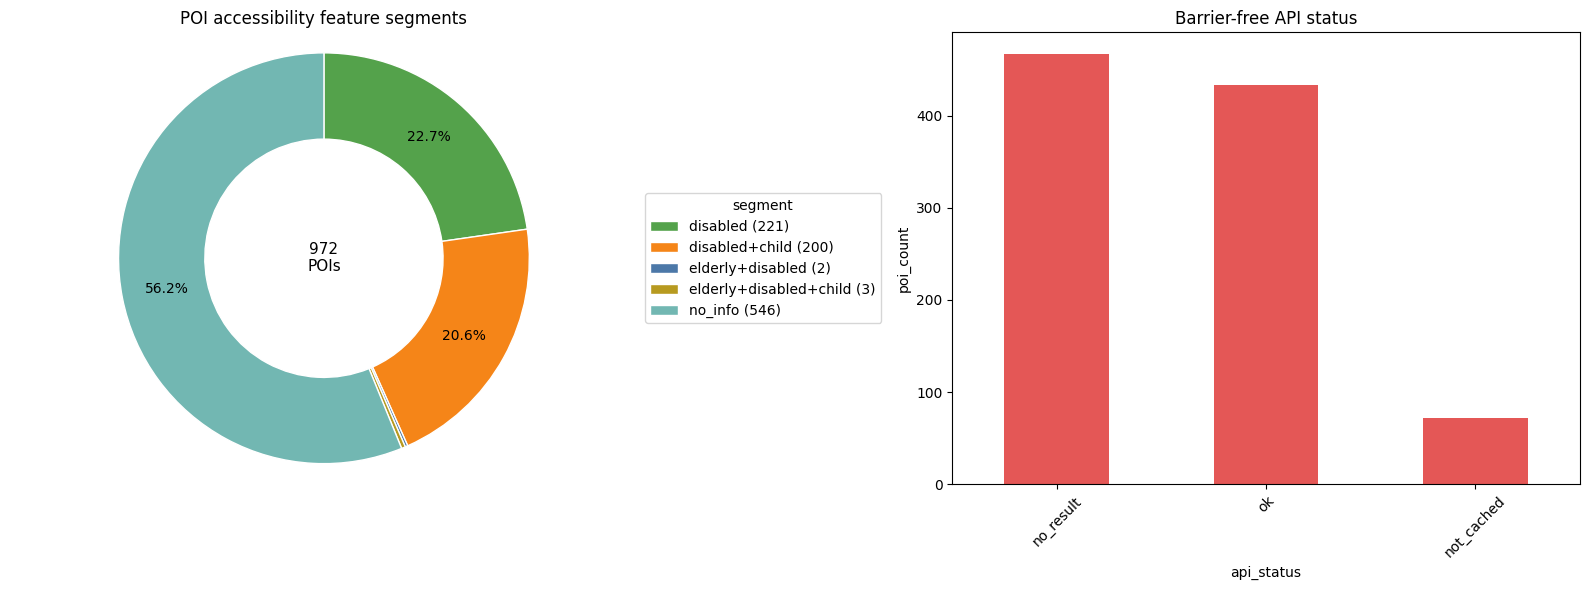

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

def accessibility_segment(row):
    labels = []
    if row["has_elderly_info"] == 1:
        labels.append("elderly")
    if row["has_disabled_info"] == 1:
        labels.append("disabled")
    if row["has_child_info"] == 1:
        labels.append("child")
    return "+".join(labels) if labels else "no_info"

accessibility_segment_counts = (
    poi_accessibility_df
    .apply(accessibility_segment, axis=1)
    .value_counts()
    .reindex(
        [
            "disabled",
            "child",
            "elderly",
            "disabled+child",
            "elderly+disabled",
            "elderly+child",
            "elderly+disabled+child",
            "no_info",
        ],
        fill_value=0,
    )
)
accessibility_segment_counts = accessibility_segment_counts[accessibility_segment_counts.gt(0)]

def autopct_large_segments(pct):
    return f"{pct:.1f}%" if pct >= 3 else ""

wedges, _, _ = axes[0].pie(
    accessibility_segment_counts,
    labels=None,
    autopct=autopct_large_segments,
    pctdistance=0.78,
    startangle=90,
    counterclock=False,
    colors=["#54A24B", "#F58518", "#4C78A8", "#B79A20", "#72B7B2", "#9D755D", "#B279A2", "#D9D9D9"],
    wedgeprops={"width": 0.42, "edgecolor": "white"},
)
axes[0].set_title("POI accessibility feature segments")
axes[0].legend(
    wedges,
    [f"{label} ({count:,})" for label, count in accessibility_segment_counts.items()],
    title="segment",
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
)
axes[0].text(
    0,
    0,
    f"{int(accessibility_segment_counts.sum()):,}\nPOIs",
    ha="center",
    va="center",
    fontsize=11,
)
axes[0].axis("equal")

api_status_summary.plot.bar(
    x="api_status",
    y="poi_count",
    ax=axes[1],
    legend=False,
    color="#E45756",
)
axes[1].set_title("Barrier-free API status")
axes[1].set_xlabel("api_status")
axes[1].set_ylabel("poi_count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

#### 2.3.4 POI 시퀀스 시각화 
* 모델의 역할을 설명하기 위해 여행자의 특징과 이를 기반으로 만들어진 여행 계획을 시각화합니다. 
* 데이터프레임이 아니라 여행 계획 형식으로 이를 출력합니다. 

In [37]:
SELECT_TRAVEL_ID = None
SELECT_DAY_INDEX = None


def sequence_content_type_label(value):
    if "content_type_label" in globals():
        return content_type_label(value)
    if pd.isna(value) or str(value).strip() == "":
        return "missing"
    content_type_id = str(value).strip()
    return content_type_map.get(content_type_id, f"unknown_{content_type_id}") if "content_type_map" in globals() else content_type_id


poi_sequence_source_df = (
    content_id_raw
    .rename(columns={"CONTENT_ID": "content_id", "CONTENT_TYPE_ID": "content_type_id"})
    [["travel_id", "day_index", "visit_order", "visit_area_id", "visit_area_nm", "content_id", "content_type_id"]]
    .dropna(subset=["content_id"])
    .copy()
)
poi_sequence_source_df["day_index"] = pd.to_numeric(poi_sequence_source_df["day_index"], errors="coerce").astype("Int64")
poi_sequence_source_df["visit_order"] = pd.to_numeric(poi_sequence_source_df["visit_order"], errors="coerce").astype("Int64")
poi_sequence_source_df = (
    poi_sequence_source_df
    .dropna(subset=["day_index", "visit_order"])
    .sort_values(["travel_id", "day_index", "visit_order", "visit_area_id"], kind="mergesort")
    .drop_duplicates(["travel_id", "day_index", "content_id"], keep="first")
    .reset_index(drop=True)
)
poi_sequence_source_df["content_type_label"] = poi_sequence_source_df["content_type_id"].map(sequence_content_type_label)

if SELECT_TRAVEL_ID is None and SELECT_DAY_INDEX is None:
    selected_key = (
        poi_sequence_source_df
        .groupby(["travel_id", "day_index"], dropna=False)
        .size()
        .rename("poi_count")
        .reset_index()
        .sort_values(["poi_count", "travel_id", "day_index"], ascending=[False, True, True], kind="mergesort")
        .iloc[0]
    )
    SELECT_TRAVEL_ID = selected_key["travel_id"]
    SELECT_DAY_INDEX = int(selected_key["day_index"])

selected_mask = poi_sequence_source_df["travel_id"].eq(str(SELECT_TRAVEL_ID))
if SELECT_DAY_INDEX is not None:
    selected_mask &= poi_sequence_source_df["day_index"].eq(int(SELECT_DAY_INDEX))

selected_poi_sequence_df = (
    poi_sequence_source_df[selected_mask]
    .sort_values(["day_index", "visit_order"], kind="mergesort")
    .reset_index(drop=True)
)
if selected_poi_sequence_df.empty:
    raise ValueError(f"No POI sequence found for travel_id={SELECT_TRAVEL_ID}, day_index={SELECT_DAY_INDEX}")

poi_sequence_view_df = selected_poi_sequence_df.copy()
poi_sequence_view_df["display_name"] = poi_sequence_view_df["visit_area_nm"].fillna(poi_sequence_view_df["content_id"])

if "poi_accessibility_df" in globals():
    accessibility_columns = [
        "content_id",
        "has_elderly_info",
        "has_disabled_info",
        "has_child_info",
        "has_any_accessibility_info",
    ]
    existing_accessibility_columns = [
        column for column in accessibility_columns if column in poi_accessibility_df.columns
    ]
    poi_sequence_view_df = poi_sequence_view_df.merge(
        poi_accessibility_df[existing_accessibility_columns].drop_duplicates("content_id"),
        on="content_id",
        how="left",
        validate="many_to_one",
    )

for column in ["has_elderly_info", "has_disabled_info", "has_child_info", "has_any_accessibility_info"]:
    if column not in poi_sequence_view_df.columns:
        poi_sequence_view_df[column] = 0
    poi_sequence_view_df[column] = poi_sequence_view_df[column].fillna(0).astype(int)

travel_context_df = (
    travel_day_df
    .merge(traveler_df, on="traveler_id", how="left", validate="many_to_one")
)
selected_context = travel_context_df[
    travel_context_df["trip_id"].eq(str(SELECT_TRAVEL_ID))
    & travel_context_df["day_index"].eq(int(SELECT_DAY_INDEX))
]

theme_columns_in_context = [column for column in theme_columns if column in selected_context.columns]
active_themes = []
if not selected_context.empty:
    selected_context_row = selected_context.iloc[0]
    active_themes = [
        column.replace("theme_", "")
        for column in theme_columns_in_context
        if int(selected_context_row[column]) == 1
    ]
else:
    selected_context_row = pd.Series(dtype="object")

poi_name_sequence = " -> ".join(poi_sequence_view_df["display_name"].astype("string").tolist())

print("selected travel_id:", SELECT_TRAVEL_ID)
print("selected day_index:", SELECT_DAY_INDEX)
print("selected POI count:", len(poi_sequence_view_df))
print("active themes:", active_themes)
print("POI name sequence:")
print(poi_name_sequence)

context_columns = [
    "trip_id",
    "day_index",
    "area_code",
    "trip_days",
    "companion_bucket",
    "residence_code",
    "gender",
    "age_grp",
    "travel_style",
    "travel_like_code",
]
display(selected_context[[column for column in context_columns if column in selected_context.columns]].head(1))
display(poi_sequence_view_df)


selected travel_id: e_e007488
selected day_index: 1
selected POI count: 11
active themes: ['hotplace_sentiment', 'culture_history', 'rest_wellness']
POI name sequence:
화성행궁 -> 수원 화성 팔달문 -> 수원 화성 남수문 -> 수원 화성 박물관 -> 창룡문 -> 수원 화성 화홍문 -> 방화수류정 -> 장안문 -> 수원 전통문화관 전통식생활 체험관 -> 수원 화성 서장대 -> 행리단길


,trip_id,day_index,area_code,trip_days,companion_bucket,residence_code,gender,age_grp,travel_style,travel_like_code
2877,e_e007488,1,suwon,2,0,11,여,20,3,50


,travel_id,day_index,visit_order,visit_area_id,visit_area_nm,content_id,content_type_id,content_type_label,display_name,has_elderly_info,has_disabled_info,has_child_info,has_any_accessibility_info
0,e_e007488,1,3,2308280004,화성행궁,129437,12,관광지,화성행궁,0,1,1,1
1,e_e007488,1,4,2308280005,수원 화성 팔달문,264386,12,관광지,수원 화성 팔달문,0,0,0,0
2,e_e007488,1,5,2308280006,수원 화성 남수문,2480899,12,관광지,수원 화성 남수문,0,1,0,1
3,e_e007488,1,6,2308280007,수원 화성 박물관,1921150,14,문화시설,수원 화성 박물관,0,1,1,1
4,e_e007488,1,7,2308280008,창룡문,264392,12,관광지,창룡문,0,1,0,1
5,e_e007488,1,8,2308280009,수원 화성 화홍문,264394,12,관광지,수원 화성 화홍문,0,1,0,1
6,e_e007488,1,9,2308280010,방화수류정,2613658,12,관광지,방화수류정,0,1,1,1
7,e_e007488,1,10,2308280011,장안문,264390,12,관광지,장안문,0,1,1,1
8,e_e007488,1,11,2308280012,수원 전통문화관 전통식생활 체험관,3080477,12,관광지,수원 전통문화관 전통식생활 체험관,0,1,0,1
9,e_e007488,1,12,2308280013,수원 화성 서장대,264408,12,관광지,수원 화성 서장대,0,0,0,0


C:\Users\82103\AppData\Local\Temp\ipykernel_8404\2079524942.py:87: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82103\AppData\Local\Temp\ipykernel_8404\2079524942.py:87: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82103\AppData\Local\Temp\ipykernel_8404\2079524942.py:87: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82103\AppData\Local\Temp\ipykernel_8404\2079524942.py:87: UserWarning: Glyph 44417 (\N{HANGUL SYLLABLE GUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82103\AppData\Local\Temp\ipykernel_8404\2079524942.py:87: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82103\AppData\Local\Temp\ipykernel_8404\2079524942.py:87: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from

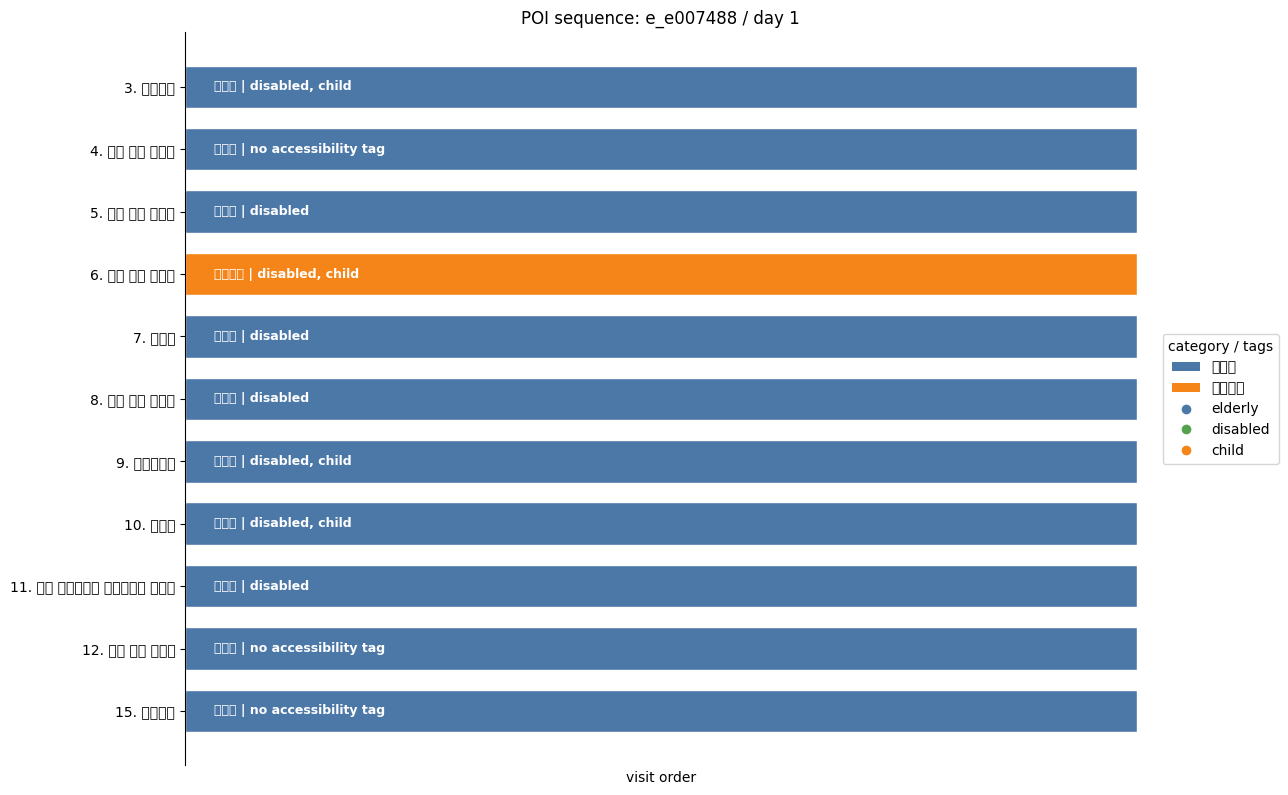

,visit_order,display_name,content_id,content_type_label,has_elderly_info,has_disabled_info,has_child_info,has_any_accessibility_info
0,3,화성행궁,129437,관광지,0,1,1,1
1,4,수원 화성 팔달문,264386,관광지,0,0,0,0
2,5,수원 화성 남수문,2480899,관광지,0,1,0,1
3,6,수원 화성 박물관,1921150,문화시설,0,1,1,1
4,7,창룡문,264392,관광지,0,1,0,1
5,8,수원 화성 화홍문,264394,관광지,0,1,0,1
6,9,방화수류정,2613658,관광지,0,1,1,1
7,10,장안문,264390,관광지,0,1,1,1
8,11,수원 전통문화관 전통식생활 체험관,3080477,관광지,0,1,0,1
9,12,수원 화성 서장대,264408,관광지,0,0,0,0


In [38]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

poi_category_color_map = {
    "관광지": "#4C78A8",
    "문화시설": "#F58518",
    "축제/공연/행사": "#E45756",
    "여행코스": "#72B7B2",
    "레포츠": "#54A24B",
    "숙박": "#EECA3B",
    "쇼핑": "#B279A2",
    "음식점": "#9D755D",
    "missing": "#BAB0AC",
}

category_labels = poi_sequence_view_df["content_type_label"].fillna("missing").astype("string")
colors = category_labels.map(lambda label: poi_category_color_map.get(label, "#8C8C8C"))
y_positions = list(range(len(poi_sequence_view_df)))

fig_height = max(5, 0.55 * len(poi_sequence_view_df) + 2)
fig, ax = plt.subplots(figsize=(13, fig_height))

ax.barh(
    y_positions,
    [1] * len(poi_sequence_view_df),
    color=colors,
    edgecolor="white",
    height=0.68,
)
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xticks([])
ax.set_yticks(y_positions)
ax.set_yticklabels(
    [
        f"{int(row.visit_order)}. {row.display_name}"
        for row in poi_sequence_view_df.itertuples(index=False)
    ],
    fontsize=10,
)
ax.set_title(f"POI sequence: {SELECT_TRAVEL_ID} / day {SELECT_DAY_INDEX}")
ax.set_xlabel("visit order")

for y, row in zip(y_positions, poi_sequence_view_df.itertuples(index=False)):
    accessibility_tags = []
    if row.has_elderly_info == 1:
        accessibility_tags.append("elderly")
    if row.has_disabled_info == 1:
        accessibility_tags.append("disabled")
    if row.has_child_info == 1:
        accessibility_tags.append("child")
    tag_text = ", ".join(accessibility_tags) if accessibility_tags else "no accessibility tag"
    ax.text(
        0.03,
        y,
        f"{row.content_type_label} | {tag_text}",
        va="center",
        ha="left",
        color="white",
        fontsize=9,
        fontweight="bold",
    )

legend_categories = [
    label for label in category_labels.drop_duplicates().tolist()
]
category_handles = [
    Patch(facecolor=poi_category_color_map.get(label, "#8C8C8C"), label=label)
    for label in legend_categories
]
accessibility_handles = [
    Line2D([0], [0], marker="o", color="w", label="elderly", markerfacecolor="#4C78A8", markersize=8),
    Line2D([0], [0], marker="o", color="w", label="disabled", markerfacecolor="#54A24B", markersize=8),
    Line2D([0], [0], marker="o", color="w", label="child", markerfacecolor="#F58518", markersize=8),
]
ax.legend(
    handles=category_handles + accessibility_handles,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    title="category / tags",
)

for spine in ["top", "right", "bottom"]:
    ax.spines[spine].set_visible(False)
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

display_columns = [
    "visit_order",
    "display_name",
    "content_id",
    "content_type_label",
    "has_elderly_info",
    "has_disabled_info",
    "has_child_info",
    "has_any_accessibility_info",
]
display(poi_sequence_view_df[display_columns])
